## 1. Implement Convolution from Scratch

### Task: 2-D Convolution / Filtering

This task implements a 2-D convolution operation manually using NumPy. The filter is moved across the input matrix using stride 1 and padding 0, and the dot product is calculated at every valid position to produce the output feature map.

In [2]:
import numpy as np


# a. Store the input and filter using NumPy arrays
input_matrix = np.array([
    [1, 1, 1, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 1, 1],
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0]
])

kernel = np.array([
    [1, 0, 1],
    [0, 1, 0],
    [1, 0, 1]
])

stride = 1
padding = 0


# Calculate the output size so we know how large the feature map will be
input_height, input_width = input_matrix.shape
kernel_height, kernel_width = kernel.shape

output_height = ((input_height - kernel_height + 2 * padding) // stride) + 1
output_width = ((input_width - kernel_width + 2 * padding) // stride) + 1

output = np.zeros((output_height, output_width), dtype=int)


# b. Slide the filter over the input matrix
for i in range(output_height):
    for j in range(output_width):

        row_start = i * stride
        col_start = j * stride

        patch = input_matrix[
            row_start:row_start + kernel_height,
            col_start:col_start + kernel_width
        ]

        # c. Compute the dot product at every valid location
        output[i, j] = np.sum(patch * kernel)


# d. Print the complete output feature map
print("Output Feature Map:")
print(output)


# e. Print the output shape
print("\nOutput Shape:")
print(output.shape)

Output Feature Map:
[[4 3 4]
 [2 4 3]
 [2 3 4]]

Output Shape:
(3, 3)


### f. Briefly explain how changing the stride from 1 to 2 would affect the output.
Changing the stride from 1 to 2 makes the filter move two positions at a time instead of one. This reduces the number of locations evaluated and changes the output feature-map size from (3 x 3) to (2 x 2). A larger stride therefore produces a smaller output and requires fewer convolution calculations.

### Observation

The (3 x 3) filter was successfully moved across the (5 x 5) input matrix using stride 1 and padding 0. The resulting output feature map had shape (3 x 3) and contained:

\[
\begin{bmatrix}
4 & 3 & 4 \\
2 & 4 & 3 \\
2 & 3 & 4
\end{bmatrix}
\]

If the stride is increased from 1 to 2, the filter moves two positions at a time, reducing the output size from (3 x 3) to \(2 x 2).

## 2. Transfer Learning: Freeze vs. Fine-Tune

Use a pretrained model such as ResNet18, ResNet50, VGG16, or another standard pretrained CNN.

Use an image-classification dataset with at least two classes.

In this task, we will compare Experiment A - Feature Extraction and Experiment B - Fine-Tuning using the same dataset and the same number of epochs.

Before starting Experiment A and Experiment B, a common setup is prepared for both experiments. These steps load and prepare the shared dataset, preprocessing, and training settings so that they do not need to be repeated twice.

In [3]:
# Import required libraries

import time                 # --- To measure how long each experiment takes
import numpy as np          # --- For working with arrays and labels
import pandas as pd         # --- To create the final comparison table
import matplotlib.pyplot as plt       # --- To plot the training loss for both experiments
import tensorflow as tf               # Import TensorFlow and Keras for loading the dataset,
                                      # building the pretrained CNN, and training the models.

from tensorflow.keras import layers, models

# Import the pretrained VGG16 model and its required image preprocessing function
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

In [4]:
# Load an image-classification dataset with at least two classes

# Load the CIFAR-10 dataset
# CIFAR-10 contains training and test images from 10 different classes
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


# Select only cat images and dog images
# In CIFAR-10:
# Class 3 = Cat
# Class 5 = Dog
train_mask = np.isin(y_train.flatten(), [3, 5])
test_mask = np.isin(y_test.flatten(), [3, 5])


# Keep only the cat and dog images from the training dataset
x_train = x_train[train_mask]
y_train = y_train[train_mask]


# Keep only the cat and dog images from the test dataset
x_test = x_test[test_mask]
y_test = y_test[test_mask]


# Change the original CIFAR-10 labels into binary labels
# Cat will be represented as 0.
# Dog will be represented as 1.
y_train = (y_train.flatten() == 5).astype(np.float32)
y_test = (y_test.flatten() == 5).astype(np.float32)


# Display the number and shape of the training and test images
print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("\nTest images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (10000, 32, 32, 3)
Training labels: (10000,)

Test images: (2000, 32, 32, 3)
Test labels: (2000,)


In [5]:
# Prepare the images for the pretrained CNN

# Set the image size that will be used by VGG16
# CIFAR-10 images are originally 32 x 32 pixels.
# We resize them to 96 x 96 so the pretrained CNN can work with a larger image size
IMG_SIZE = 96


# Set how many images will be processed together in one batch
BATCH_SIZE = 32


# Create a function that resizes and prepares each image for VGG16
def prepare_image(image, label):

    # Resize the image from 32 x 32 to 96 x 96 pixels
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Apply the preprocessing required by VGG16
    image = preprocess_input(image)

    # Return the prepared image together with its label
    return image, label


# Create the training dataset
train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, y_train))

    # Shuffle the training images so the model does not learn from a fixed order
    .shuffle(len(x_train))

    # Resize and preprocess the images
    .map(prepare_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Group the images into batches
    .batch(BATCH_SIZE)

    # Prepare future batches while the current batch is being processed
    .prefetch(tf.data.AUTOTUNE)
)


# Create the test dataset using the same image preparation
test_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test))

    # Resize and preprocess the test images.
    .map(prepare_image, num_parallel_calls=tf.data.AUTOTUNE)

    # Group the test images into batches
    .batch(BATCH_SIZE)

    # Prepare future batches while the model is processing the current batch
    .prefetch(tf.data.AUTOTUNE)
)

### Experiment A - Feature Extraction

In this experiment, the pretrained VGG16 convolutional/base layers are frozen so that their existing weights do not change during training. The original classification layer is replaced with a new classifier for the cat and dog classes, and only the new classifier is trained.

In [7]:
# 1. Load the pretrained network
# VGG16 is loaded with ImageNet weights
# include_top=False removes the original VGG16 classification layers
# because we will create a new classifier for cats and dogs
base_model_A = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("Pretrained VGG16 network loaded successfully.")

Pretrained VGG16 network loaded successfully.


In [8]:
# 2. Freeze the convolutional/base layers
# This keeps all pretrained VGG16 convolutional weights unchanged
# while Experiment A is being trained
base_model_A.trainable = False

print("VGG16 convolutional/base layers frozen.")

VGG16 convolutional/base layers frozen.


In [9]:
# 3. Replace the final classification layer
# GlobalAveragePooling2D converts the feature maps into a single feature vector
# Dense(1) with sigmoid is used because this is a binary classification problem:
# Cat = 0 and Dog = 1
model_A = models.Sequential([
    base_model_A,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation="sigmoid")
])

# Display the structure of the new model.
model_A.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
# Compile the model before training
# Binary crossentropy is used because there are only two classes
model_A.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [11]:
# a. Report the number of trainable parameters
# Only the new classifier should be trainable because the VGG16 base is frozen
trainable_params_A = np.sum([
    np.prod(variable.shape)
    for variable in model_A.trainable_weights
])

print("Trainable Parameters:", trainable_params_A)

Trainable Parameters: 513


In [12]:
# b. Train for the same number of epochs
# Use the same number of epochs for Experiment A and Experiment B
# so that the comparison between the two approaches is fair
EPOCHS = 5

In [14]:
# c. Record training time
# Start the timer immediately before training begins
start_time_A = time.time()


# 4. Train only the new classifier
# The frozen VGG16 convolutional/base layers do not update during training
history_A = model_A.fit(
    train_dataset,
    epochs=EPOCHS
)


# Stop the timer after training is complete
training_time_A = time.time() - start_time_A

print("\nTraining Time:", round(training_time_A, 2), "seconds")

Epoch 1/5


C:\Users\paran\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


313/313 ━━━━━━━━━━━━━━━━━━━━ 177s 561ms/step - accuracy: 0.7300 - loss: 1.0933
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 156s 499ms/step - accuracy: 0.8110 - loss: 0.5555
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 533ms/step - accuracy: 0.8273 - loss: 0.4389
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 167s 532ms/step - accuracy: 0.8400 - loss: 0.3728
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 157s 500ms/step - accuracy: 0.8461 - loss: 0.3526

Training Time: 823.42 seconds


In [15]:
# d. Report test or validation accuracy
# Evaluate the trained model using the test dataset
test_loss_A, test_accuracy_A = model_A.evaluate(test_dataset)

print("Test Accuracy:", round(test_accuracy_A * 100, 2), "%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 33s 524ms/step - accuracy: 0.8300 - loss: 0.4141
Test Accuracy: 83.0 %


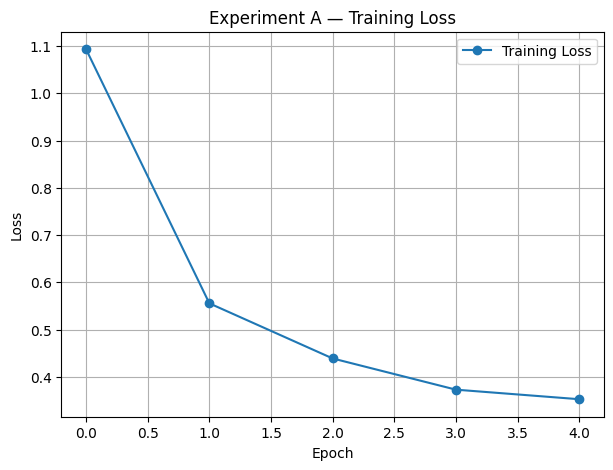

In [16]:
# e. Plot training loss
# This shows how the training loss changes across the epochs
plt.figure(figsize=(7, 5))
plt.plot(
    history_A.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.title("Experiment A — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Observation

The pretrained VGG16 convolutional/base layers were successfully frozen, leaving only **513 trainable parameters** in the new classifier. Over 5 epochs, the training accuracy increased from **73.0% to 84.61%**, while the training loss decreased from **1.0933 to 0.3526**. The model achieved a **test accuracy of 83.0%**. The total training time was **823.42 seconds**. These results show that the frozen VGG16 features were useful for distinguishing between cat and dog images while only the new classifier was trained.

### Experiment B - Fine-Tuning

In this experiment, a pretrained VGG16 network is used again. The earlier convolutional layers remain frozen, while the last convolutional block is unfrozen so its weights can be updated together with the new classifier during training.

In [17]:
# 1. Start with the pretrained network
# Load a new VGG16 model with ImageNet weights
# include_top=False removes the original VGG16 classification layers
# because we will create a new classifier for cats and dogs
base_model_B = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

print("Pretrained VGG16 network loaded successfully.")

Pretrained VGG16 network loaded successfully.


In [18]:
# 2. Unfreeze at least the last convolutional block
# First, freeze all VGG16 convolutional/base layers
base_model_B.trainable = True


# Keep the earlier convolutional blocks frozen
# Only layers whose names begin with "block5" will remain trainable
for layer in base_model_B.layers:
    if not layer.name.startswith("block5"):
        layer.trainable = False


# Display which layers are frozen and which layers are trainable
for layer in base_model_B.layers:
    print(layer.name, "Trainable:", layer.trainable)

input_layer_2 Trainable: False
block1_conv1 Trainable: False
block1_conv2 Trainable: False
block1_pool Trainable: False
block2_conv1 Trainable: False
block2_conv2 Trainable: False
block2_pool Trainable: False
block3_conv1 Trainable: False
block3_conv2 Trainable: False
block3_conv3 Trainable: False
block3_pool Trainable: False
block4_conv1 Trainable: False
block4_conv2 Trainable: False
block4_conv3 Trainable: False
block4_pool Trainable: False
block5_conv1 Trainable: True
block5_conv2 Trainable: True
block5_conv3 Trainable: True
block5_pool Trainable: True


In [26]:
# Add the same classifier used in Experiment A
# GlobalAveragePooling2D converts the VGG16 feature maps into a feature vector
# Dense(1) with sigmoid predicts Cat = 0 or Dog = 1
model_B = models.Sequential([
    base_model_B,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation="sigmoid")
])


# Display the structure of the fine-tuned model
model_B.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 7,079,937 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [27]:
# Compile the fine-tuned model
# A small learning rate is used because we are updating pretrained VGG16 weights
model_B.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
# a. Report the number of trainable parameters
# Experiment B should have many more trainable parameters than Experiment A
# because the last VGG16 convolutional block is now trainable
trainable_params_B = np.sum([
    np.prod(variable.shape)
    for variable in model_B.trainable_weights
])

print("Trainable Parameters:", trainable_params_B)

Trainable Parameters: 7079937


In [29]:
# b. Train for the same number of epochs
# Use the same 5 epochs that were used for Experiment A
# so that both experiments can be compared fairly
print("Number of Epochs:", EPOCHS)

Number of Epochs: 5


In [30]:
# c. Record training time
# Start the timer immediately before fine-tuning begins
start_time_B = time.time()


# 3. Train the unfrozen layers and classifier
# The block5 convolutional layers and the new classifier
# will update their weights during training.
history_B = model_B.fit(
    train_dataset,
    epochs=EPOCHS
)


# Stop the timer after training is complete
training_time_B = time.time() - start_time_B

print("\nTraining Time:", round(training_time_B, 2), "seconds")

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 193s 612ms/step - accuracy: 0.7577 - loss: 0.6707
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 194s 620ms/step - accuracy: 0.8765 - loss: 0.2883
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 194s 621ms/step - accuracy: 0.9293 - loss: 0.1792
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 199s 634ms/step - accuracy: 0.9653 - loss: 0.1063
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 194s 620ms/step - accuracy: 0.9887 - loss: 0.0589

Training Time: 974.44 seconds


In [31]:
# d. Report test or validation accuracy
# Evaluate the fine-tuned model using the same test dataset that was used for Experiment A
test_loss_B, test_accuracy_B = model_B.evaluate(test_dataset)

print("Test Accuracy:", round(test_accuracy_B * 100, 2), "%")

63/63 ━━━━━━━━━━━━━━━━━━━━ 30s 473ms/step - accuracy: 0.8485 - loss: 0.4239
Test Accuracy: 84.85 %


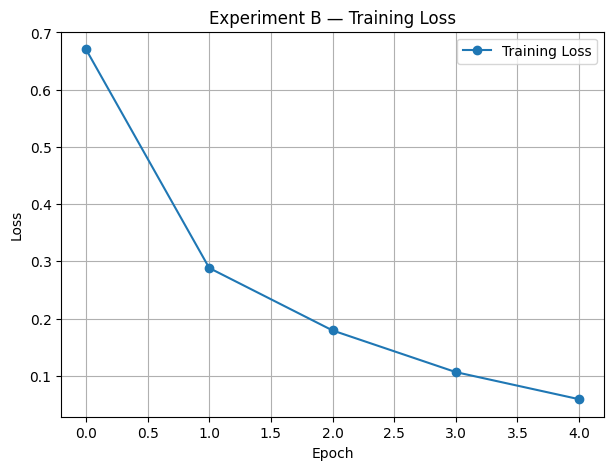

In [32]:
# e. Plot training loss.
# This shows how the training loss changes during the 5 fine-tuning epochs.
plt.figure(figsize=(7, 5))

plt.plot(
    history_B.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.title("Experiment B — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The last convolutional block of VGG16 was successfully unfrozen and trained together with the new classifier. This increased the number of trainable parameters to **7,079,937**. Over 5 epochs, the training accuracy increased from **75.77% to 98.87%**, while the training loss decreased from **0.6707 to 0.0589**. The model achieved a **test accuracy of 84.85%**, with a total training time of **974.44 seconds**. Fine-tuning slightly improved the test accuracy compared with Experiment A, but the much higher training accuracy than test accuracy suggests some overfitting.

### f. Compare the two approaches in a table:

| Method | Trainable Parameters | Training Time | Accuracy |
|---|---:|---:|---:|
| Frozen Feature Extractor | 513 | 823.42 seconds | 83.0% |
| Fine-Tuned Network | 7,079,937 | 974.44 seconds | 84.85% |

### g. Discussion of Results

The Frozen Feature Extractor trained only **513 parameters** and achieved a test accuracy of **83.0%** in **823.42 seconds**. The Fine-Tuned Network trained **7,079,937 parameters** and achieved a slightly higher test accuracy of **84.85%** in **974.44 seconds**. Fine-tuning took longer **because the last convolutional block and the new classifier were both updated during training, while the frozen model only updated the new classifier.** The fine-tuned model was able to adapt some of VGG16's pretrained features more closely to the cat and dog dataset, which likely helped improve its test accuracy. However, its training accuracy reached **98.87%**, which was much higher than its test accuracy and suggests some overfitting. In comparison, the frozen feature extractor required less computation and trained faster because most of the pretrained VGG16 weights remained unchanged. Overall, fine-tuning produced slightly better test performance, but it required more trainable parameters and a longer training time.